In [1]:
%run "coli starting run.ipynb"

In [2]:


score_borad = data_create(0,0,0,0)
for i in range(50):
    true_score = i*10+101
    score_borad = pd.concat([score_borad,data_create(40,my_floor(true_score,-2),true_score,0)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(20,my_floor(true_score,-2),true_score,1)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(40,my_floor(true_score,-2),true_score,2)]).reset_index(drop=True)

score_borad = pd.concat([score_borad,data_create(50,200,349,3)]).reset_index(drop=True)
score_borad = pd.concat([score_borad,data_create(50,500,350,3)]).reset_index(drop=True)

score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100.0,101,0,0,0,0,0,0,17.0,100.0
1,100.0,101,0,0,0,0,0,0,17.0,100.0
2,100.0,101,0,0,0,0,0,0,7.0,100.0
3,100.0,101,0,0,0,0,0,0,1.0,100.0
4,100.0,101,0,0,0,0,0,0,6.0,100.0
...,...,...,...,...,...,...,...,...,...,...
5095,500.0,350,0,0,0,0,0,3,19.0,500.0
5096,500.0,350,0,0,0,0,0,3,0.0,500.0
5097,500.0,350,0,0,0,0,0,3,1.0,500.0
5098,500.0,350,0,0,0,0,0,3,14.0,500.0


In [3]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
3162,490.0,411,5,10,8,6,3,2,10.0,400.0,90.0
4732,670.0,571,0,8,11,6,6,0,8.0,500.0,170.0
4224,600.0,521,0,3,11,1,7,0,3.0,500.0,100.0
1046,190.0,201,0,0,7,0,2,1,0.0,200.0,-10.0
598,110.0,151,5,2,6,1,2,2,2.0,100.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...
1897,210.0,281,5,2,0,1,0,2,2.0,200.0,10.0
2306,380.0,331,0,17,17,12,2,0,17.0,300.0,80.0
361,120.0,131,5,2,11,1,4,2,2.0,100.0,20.0
5027,230.0,349,0,2,1,2,0,3,2.0,200.0,30.0


<AxesSubplot:xlabel='score', ylabel='true score'>

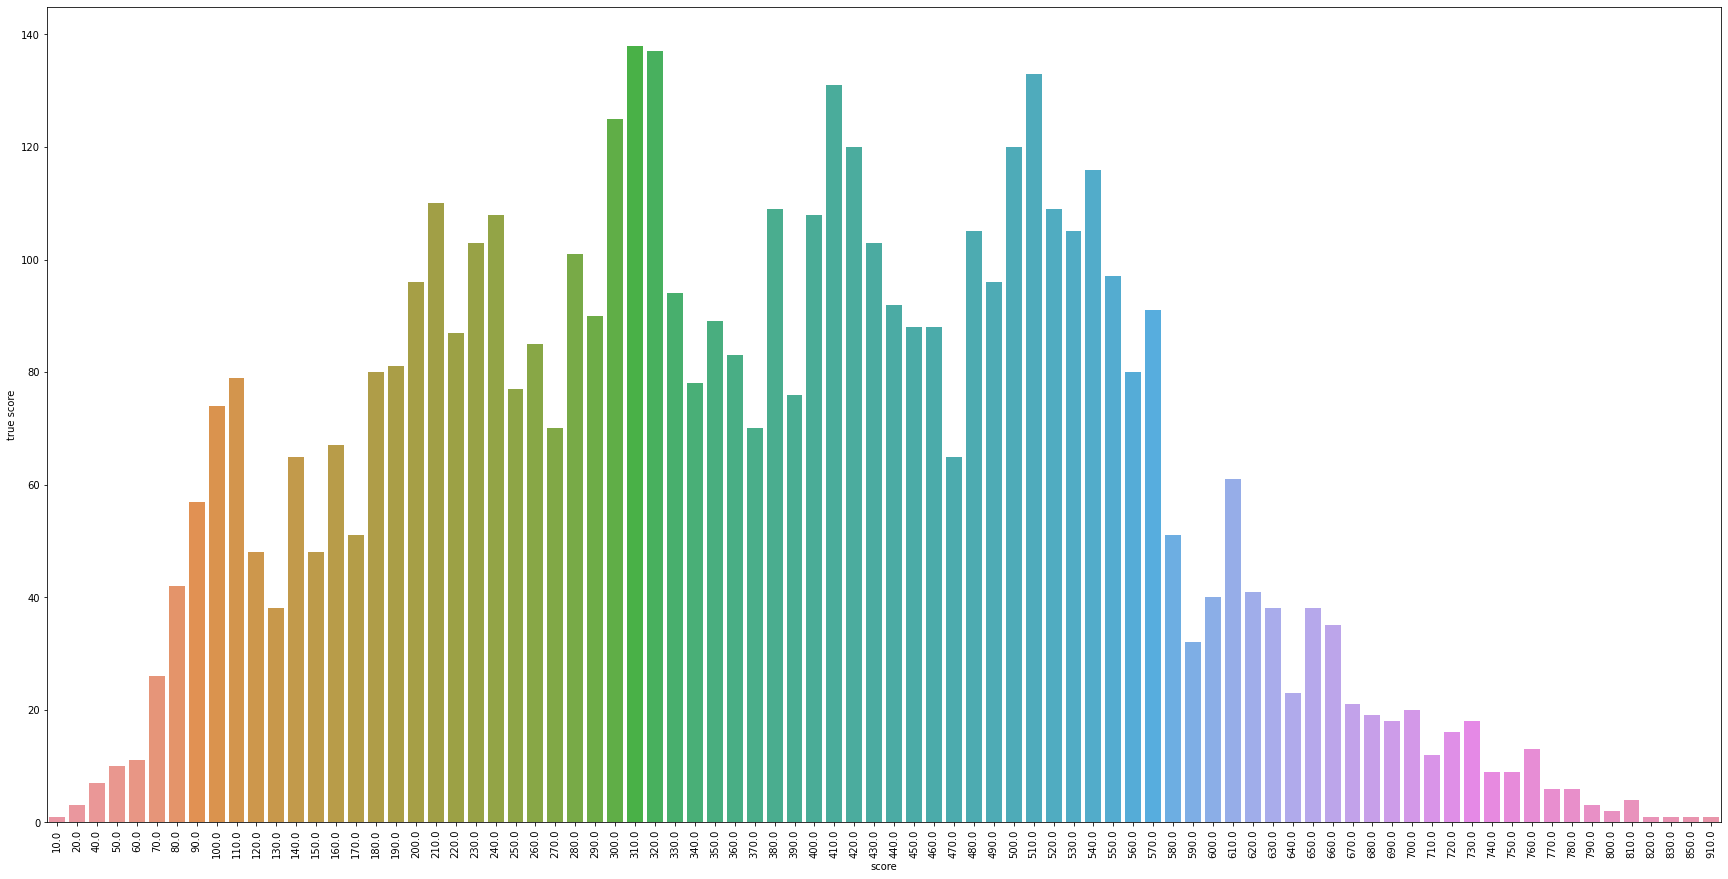

In [4]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

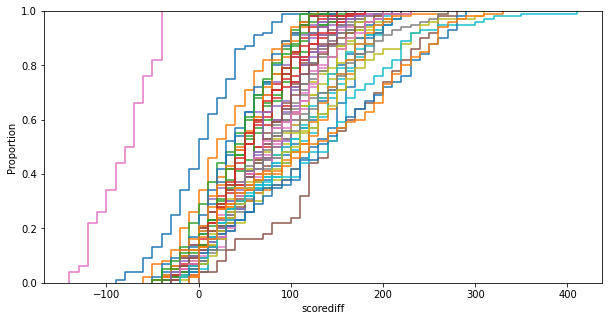

In [5]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [6]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

att count                    att win                 def count  \
type               0    1      2      3       0    1     2    3         0   
true score                                                                  
101             9.35  0.0   7.70    NaN    4.20  0.0  3.75  NaN      9.72   
111            10.57  0.0   8.50    NaN    5.72  0.0  4.60  NaN      9.68   
121             9.32  0.0   9.60    NaN    5.17  0.0  5.08  NaN     10.22   
131             8.82  0.0   8.90    NaN    5.22  0.0  5.17  NaN     10.22   
141             9.00  0.0   7.50    NaN    4.88  0.0  4.60  NaN      8.28   
151             8.10  0.0   9.10    NaN    5.05  0.0  5.62  NaN      8.65   
161            11.32  0.0   9.72    NaN    6.80  0.0  6.28  NaN      9.20   
171            10.07  0.0   9.35    NaN    6.30  0.0  6.10  NaN      6.80   
181             9.30  0.0   7.75    NaN    6.30  0.0  5.28  NaN      7.12   
191             9.65  0.0   8.88    NaN    6.90  0.0  6.60  NaN      6.47   
201             9.43  0.0  10.18    NaN    5.03  0.0  5.88  NaN     11.62   
211             9.62  0.0   8.70    NaN    5.25  0.0  4.95  NaN     10.60   
221             8.03  0.0   8.93    NaN    4.47  0.0  4.92  NaN      9.53   
231             8.45  0.0   8.38    NaN    4.97  0.0  4.97  NaN     10.60   
241            10.40  0.0   7.75    NaN    6.17  0.0  4.85  NaN     10.70   
251             8.88  0.0   9.20    NaN    5.35  0.0  6.03  NaN      9.18   
261             8.72  0.0   9.55    NaN    5.42  0.0  6.33  NaN      7.90   
271             9.47  0.0   8.35    NaN    6.12  0.0  5.90  NaN      8.38   
281             7.88  0.0   9.05    NaN    4.95  0.0  6.35  NaN      6.33   
291             9.88  0.0   9.60    NaN    6.95  0.0  6.95  NaN      6.85   
301            10.45  0.0   9.53    NaN    5.80  0.0  5.58  NaN     10.55   
311            10.07  0.0   7.95    NaN    5.45  0.0  4.55  NaN     11.47   
321            10.80  0.0   9.15    NaN    6.00  0.0  5.45  NaN     10.75   
331             9.97  0.0   8.47    NaN    5.85  0.0  5.22  NaN     11.22   
341             9.22  0.0   8.30    NaN    5.62  0.0  5.38  NaN     10.25   
349              NaN  NaN    NaN   9.26     NaN  NaN   NaN  7.4       NaN   
350              NaN  NaN    NaN  10.78     NaN  NaN   NaN  3.4       NaN   
351            10.15  0.0   7.83    NaN    5.92  0.0  5.05  NaN      8.07   
361            10.28  0.0   7.80    NaN    6.72  0.0  5.15  NaN      7.60   
371            10.10  0.0   8.70    NaN    6.67  0.0  6.35  NaN      7.85   
381             8.88  0.0   8.88    NaN    6.22  0.0  6.35  NaN      7.35   
391            10.78  0.0   9.35    NaN    7.62  0.0  6.83  NaN      6.20   
401             8.57  0.0   9.20    NaN    4.70  0.0  5.17  NaN     10.72   
411             9.55  0.0   9.18    NaN    5.12  0.0  5.42  NaN     11.10   
421            10.40  0.0   9.43    NaN    6.00  0.0  5.92  NaN     10.57   
431            10.88  0.0   9.65    NaN    6.70  0.0  5.97  NaN     10.10   
441             9.25  0.0   9.72    NaN    5.53  0.0  6.08  NaN      8.53   
451             6.55  0.0   9.35    NaN    4.15  0.0  6.28  NaN      7.17   
461             8.65  0.0  10.62    NaN    5.78  0.0  7.30  NaN      9.60   
471             9.55  0.0   9.10    NaN    6.67  0.0  6.38  NaN      6.90   
481            12.07  0.0   8.90    NaN    8.40  0.0  6.72  NaN      8.62   
491             9.50  0.0   8.15    NaN    6.62  0.0  6.30  NaN      6.22   
501             8.82  0.0   7.45    NaN    5.00  0.0  4.40  NaN     10.70   
511             9.30  0.0   8.22    NaN    5.38  0.0  5.17  NaN     12.72   
521             9.60  0.0   8.78    NaN    5.80  0.0  5.75  NaN     11.65   
531             9.55  0.0   8.45    NaN    6.08  0.0  5.53  NaN     11.22   
541            10.35  0.0   7.95    NaN    6.50  0.0  5.35  NaN     11.35   
551             8.60  0.0   9.12    NaN    5.83  0.0  6.60  NaN     10.25   
561             9.35  0.0   9.00    NaN    6.85  0.0  6.67  NaN     10.25   
571    

In [7]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399]

att count                   att win                 def count  \
type               0    1     2      3       0    1     2    3         0   
true score                                                                 
301            10.45  0.0  9.53    NaN    5.80  0.0  5.58  NaN     10.55   
311            10.07  0.0  7.95    NaN    5.45  0.0  4.55  NaN     11.47   
321            10.80  0.0  9.15    NaN    6.00  0.0  5.45  NaN     10.75   
331             9.97  0.0  8.47    NaN    5.85  0.0  5.22  NaN     11.22   
341             9.22  0.0  8.30    NaN    5.62  0.0  5.38  NaN     10.25   
349              NaN  NaN   NaN   9.26     NaN  NaN   NaN  7.4       NaN   
350              NaN  NaN   NaN  10.78     NaN  NaN   NaN  3.4       NaN   
351            10.15  0.0  7.83    NaN    5.92  0.0  5.05  NaN      8.07   
361            10.28  0.0  7.80    NaN    6.72  0.0  5.15  NaN      7.60   
371            10.10  0.0  8.70    NaN    6.67  0.0  6.35  NaN      7.85   
381             8.88  0.0  8.88    NaN    6.22  0.0  6.35  NaN      7.35   
391            10.78  0.0  9.35    NaN    7.62  0.0  6.83  NaN      6.20   

                               def win                   int_score         \
type           1      2      3       0     1     2     3         0      1   
true score                                                                  
301         7.65  10.70    NaN    2.65  2.60  3.08   NaN     300.0  300.0   
311         6.10  10.97    NaN    3.50  2.10  3.67   NaN     300.0  300.0   
321         6.45  10.22    NaN    3.20  2.55  3.70   NaN     300.0  300.0   
331         5.35   9.53    NaN    4.03  2.55  3.50   NaN     300.0  300.0   
341         5.75   7.83    NaN    3.67  3.15  3.00   NaN     300.0  300.0   
349          NaN    NaN   4.32     NaN   NaN   NaN  1.96       NaN    NaN   
350          NaN    NaN  14.30     NaN   NaN   NaN  2.26       NaN    NaN   
351         3.60   6.85    NaN    2.77  2.15  2.95   NaN     300.0  300.0   
361         2.90   6.22    NaN    2.62  1.45  2.77   NaN     300.0  300.0   
371         1.45   5.38    NaN    3.23  0.80  2.23   NaN     300.0  300.0   
381         1.15   4.38    NaN    2.88  0.70  2.12   NaN     300.0  300.0   
391         0.60   3.62    NaN    2.12  0.45  1.85   NaN     300.0  300.0   

                         play_time                      score                 \
type            2      3         0    1      2      3       0      1       2   
true score                                                                     
301         300.0    NaN     10.45  0.0  10.45    NaN  343.50  301.5  357.25   
311         300.0    NaN     10.07  0.0   8.38    NaN  353.00  302.0  357.50   
321         300.0    NaN     10.80  0.0   9.80    NaN  360.50  312.0  380.75   
331         300.0    NaN      9.97  0.0   9.00    NaN  384.25  323.0  381.75   
341         300.0    NaN      9.22  0.0   8.72    NaN  384.25  337.0  390.00   
349           NaN  200.0       NaN  NaN    NaN   9.26     NaN    NaN     NaN   
350           NaN  500.0       NaN  NaN    NaN  10.78     NaN    NaN     NaN   
351         300.0    NaN     10.15  0.0   8.18    NaN  378.75  328.5  393.25   
361         300.0    NaN     10.28  0.0   8.43    NaN  401.75  314.5  397.50   
371         300.0    NaN     10.10  0.0   9.10    NaN  417.50  309.5  416.50   
381         300.0    NaN      8.88  0.0   9.15    NaN  410.75  309.5  421.75   
391         300.0    NaN     10.78  0.0  10.03    NaN  422.75  307.5  430.50   

                  scorediff                      skiped time                 
type            3         0     1       2      3           0    1    2    3  
true score                                                                   
301           NaN     43.50   1.5   57.25    NaN         0.0  0.0  5.0  NaN  
311           NaN     53.00   2.0   57.50    NaN         0.0  0.0  5.0  NaN  
321           NaN     60.50  12.0   80.75    NaN         0.0  0.0  5.0  NaN  
331           NaN     84.25  23.0   81.75    

In [8]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[400:499][['att count','def count','scorediff']]

att count                 def count                  scorediff  \
type               0    1      2   3         0     1      2   3         0   
true score                                                                  
401             8.57  0.0   9.20 NaN     10.72  7.50  12.30 NaN     46.25   
411             9.55  0.0   9.18 NaN     11.10  6.75   9.47 NaN     54.50   
421            10.40  0.0   9.43 NaN     10.57  6.85   9.47 NaN     76.75   
431            10.88  0.0   9.65 NaN     10.10  5.60   9.00 NaN     83.50   
441             9.25  0.0   9.72 NaN      8.53  5.35   7.35 NaN     83.25   
451             6.55  0.0   9.35 NaN      7.17  4.25   7.12 NaN     64.50   
461             8.65  0.0  10.62 NaN      9.60  3.95   5.55 NaN    101.00   
471             9.55  0.0   9.10 NaN      6.90  1.75   5.08 NaN    107.00   
481            12.07  0.0   8.90 NaN      8.62  1.55   4.12 NaN    141.00   
491             9.50  0.0   8.15 NaN      6.22  0.80   3.05 NaN    115.75   

                              
type           1       2   3  
true score                    
401         12.0   80.50 NaN  
411         24.0   70.00 NaN  
421         24.5   87.00 NaN  
431         20.5   90.25 NaN  
441         20.0  103.75 NaN  
451         28.0  115.00 NaN  
461         31.0  127.00 NaN  
471         18.5  122.25 NaN  
481         17.5  126.25 NaN  
491         11.5  119.00 NaN